# Quick Example: NUTS over effectful models

This notebook walks through four short demos that show what `effectful_mcmc` looks like in practice. We start with a basic Bayesian linear regression, move to a small hierarchical model (the classic eight schools), pause to ask **why HMC/NUTS specifically** (the funnel pathology, its fix via non-centered reparameterization, and a side-by-side against vanilla random-walk Metropolis), and finish with a counterfactual analysis that exercises what the bridge is actually *for* — composing handlers with MCMC.

Distributions come from `effectful.handlers.numpyro` (term-aware constructors that accept both eager arrays and free-variable terms). The primitives `sample`, `factor`, `param`, `deterministic` are `@defop`s, so any effectful handler can intercept them.

To run this locally:

```bash
pip install -e .
jupyter notebook docs/quickstart.ipynb
```

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr

import matplotlib.pyplot as plt
import numpy as np

from effectful.handlers.numpyro import Normal, HalfNormal
from effectful.ops.semantics import handler

from effectful_mcmc import sample, MCMC, NUTS, Intervene

jax.config.update("jax_platform_name", "cpu")  # demo is small enough that CPU is fastest

/Users/datnguyen/HMC_NUTS_Effectful/effectful_mcmc/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Linear regression

A small synthetic dataset: $N = 50$ points drawn from $y = \alpha + \beta\, x + \varepsilon$ with $\alpha = 2.0$, $\beta = -1.5$, and $\varepsilon \sim \mathcal{N}(0, 0.5)$. We then infer the posterior over $\alpha, \beta, \sigma$ using

$$
\alpha \sim \mathcal{N}(0, 10), \quad
\beta \sim \mathcal{N}(0, 10), \quad
\sigma \sim \mathrm{HalfNormal}(2).
$$

The model just calls `sample(...)` once per parameter and once for the likelihood. Returning the per-site terms lets us index `mcmc.get_samples()` by `term.op` directly — no string names to keep in sync. (Pass `name=` to `sample(...)` if you also want string-keyed access, e.g. for ArviZ or for `Intervene`; we do this in section 3.)

In [2]:
# Synthetic regression dataset
true_alpha, true_beta, true_sigma = 2.0, -1.5, 0.5
N = 50

key_data = jr.PRNGKey(0)
k_x, k_noise = jr.split(key_data)
x_data = jr.uniform(k_x, (N,), minval=-2.0, maxval=2.0)
y_data = true_alpha + true_beta * x_data + true_sigma * jr.normal(k_noise, (N,))

print(f"Generated {N} points with alpha={true_alpha}, beta={true_beta}, sigma={true_sigma}")

Generated 50 points with alpha=2.0, beta=-1.5, sigma=0.5


In [3]:
def linear_regression(x, y):
    alpha = sample(Normal(0.0, 10.0))
    beta  = sample(Normal(0.0, 10.0))
    sigma = sample(HalfNormal(2.0))
    sample(Normal(alpha + beta * x, sigma), obs=y)
    return alpha, beta, sigma                          # return per-site handles

mcmc = MCMC(NUTS(linear_regression), num_warmup=500, num_samples=1000, progress_bar=False)
mcmc.run(jr.PRNGKey(1), x_data, y_data)

# Posteriors keyed by the underlying Operation — `term.op` recovers it.
alpha_t, beta_t, sigma_t = mcmc.model_return_value
samples = mcmc.get_samples()

for term, label, true in [(alpha_t, "alpha", true_alpha),
                          (beta_t,  "beta",  true_beta),
                          (sigma_t, "sigma", true_sigma)]:
    post = samples[term.op]
    print(f"{label}: posterior mean = {float(post.mean()):+.3f}  "
          f"std = {float(post.std()):.3f}  (truth = {true:+.2f})")

alpha: posterior mean = +1.770  std = 0.081  (truth = +2.00)
beta: posterior mean = -1.477  std = 0.067  (truth = -1.50)
sigma: posterior mean = +0.568  std = 0.059  (truth = +0.50)


The chain recovers each parameter close to its true value — the posterior means are within roughly a couple of posterior std, which is the kind of finite-sample sampling noise you expect from $N = 50$ noisy observations rather than anything to investigate.

`mcmc.print_summary()` reuses NumPyro's own diagnostic table, since the bridge forwards post-run attribute access to `numpyro.infer.MCMC` via `__getattr__`. The site labels look like `_site_<hex>` because we didn't pass `name=` to the `sample(...)` calls; for ArviZ-style string keys, add `name="alpha"` etc.

In [4]:
mcmc.print_summary()


                       mean       std    median      5.0%     95.0%     n_eff     r_hat
  _site_11a66dc40     -1.48      0.07     -1.48     -1.58     -1.36    882.47      1.00
  _site_11a6fcb30      1.77      0.08      1.77      1.63      1.89    818.83      1.00
  _site_11a71cf80      0.57      0.06      0.56      0.47      0.65    981.31      1.00

Number of divergences: 0


### Did the inference reproduce the data?

The standard Bayesian sanity check: a **posterior predictive plot** overlays the inferred regression line (with its uncertainty band) onto the actual data. If the band brackets the data while passing close to the true generating line, the inference is doing its job. We pair it with the **joint posterior** $(\alpha, \beta)$ to show the parameter correlation structure — finite data on a regression $y = \alpha + \beta x$ produces a negative correlation between intercept and slope, which is exactly what posterior pair plots are good at exposing.

(Trace plots and per-parameter diagnostics are useful too, but `mcmc.print_summary()` already showed $\hat{R} = 1.00$ for every site, which is the canonical mixing certificate.)

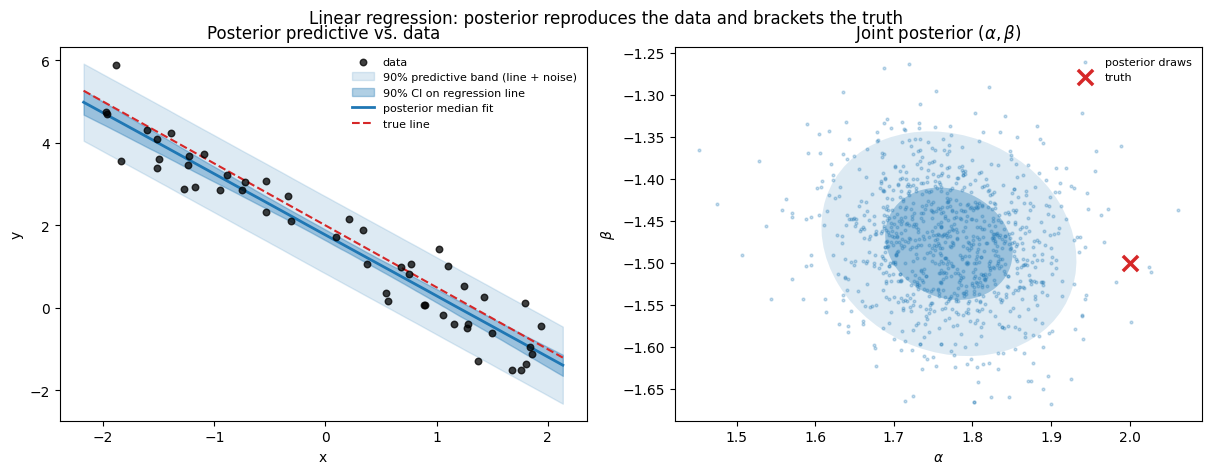

In [5]:
alpha_samples = np.asarray(samples[alpha_t.op])
beta_samples  = np.asarray(samples[beta_t.op])
sigma_samples = np.asarray(samples[sigma_t.op])

# Posterior predictive: for each posterior draw, evaluate the regression line
# on a dense x-grid, then summarise across draws.
xs = np.linspace(float(x_data.min()) - 0.2, float(x_data.max()) + 0.2, 200)
y_lines = alpha_samples[:, None] + beta_samples[:, None] * xs[None, :]   # (S, X)
y_lo, y_mid, y_hi = np.quantile(y_lines, [0.05, 0.5, 0.95], axis=0)

# Wider band that also includes one-sigma observation noise — the band the
# next observation should fall in, not just where the regression line lives.
pred_lo = y_mid - 1.645 * sigma_samples.mean()
pred_hi = y_mid + 1.645 * sigma_samples.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# Panel 1: data + posterior predictive + truth
ax = axes[0]
ax.scatter(np.asarray(x_data), np.asarray(y_data),
           color="black", s=22, alpha=0.75, label="data", zorder=5)
ax.fill_between(xs, pred_lo, pred_hi, color="C0", alpha=0.15,
                label="90% predictive band (line + noise)")
ax.fill_between(xs, y_lo,   y_hi,   color="C0", alpha=0.35,
                label="90% CI on regression line")
ax.plot(xs, y_mid, color="C0", lw=2.0, label="posterior median fit")
ax.plot(xs, true_alpha + true_beta * xs, color="C3", lw=1.5, ls="--",
        label="true line")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Posterior predictive vs. data")
ax.legend(loc="upper right", frameon=False, fontsize=8)

# Panel 2: joint posterior (alpha, beta), with the truth as a target
ax = axes[1]
ax.scatter(alpha_samples, beta_samples, s=4, alpha=0.25, color="C0",
           label="posterior draws")
ax.scatter([true_alpha], [true_beta], color="C3", marker="x", s=120,
           lw=2.5, label="truth", zorder=5)
# 1- and 2-sigma joint contours via empirical covariance (concentration ellipses)
mean = np.array([alpha_samples.mean(), beta_samples.mean()])
cov  = np.cov(alpha_samples, beta_samples)
vals, vecs = np.linalg.eigh(cov)
order = vals.argsort()[::-1]
vals, vecs = vals[order], vecs[:, order]
angle = float(np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0])))
from matplotlib.patches import Ellipse
for k, alpha_fill in [(1, 0.35), (2, 0.15)]:
    w, h = 2 * k * np.sqrt(vals)
    ax.add_patch(Ellipse(mean, w, h, angle=angle,
                         facecolor="C0", alpha=alpha_fill, edgecolor="none"))
ax.set_xlabel(r"$\alpha$"); ax.set_ylabel(r"$\beta$")
ax.set_title(r"Joint posterior $(\alpha, \beta)$")
ax.legend(loc="upper right", frameon=False, fontsize=8)

fig.suptitle("Linear regression: posterior reproduces the data and brackets the truth",
             y=1.02)
plt.show()

## 2. Eight schools

Eight schools each ran a coaching program and reported an estimated treatment effect $y_j$ together with an observational standard error $\sigma_j$. The hierarchical model partially pools the school-level effects $\theta_j$ toward a shared population mean $\mu$ with a shared spread $\tau$:

$$
\mu \sim \mathcal{N}(0, 10), \quad
\tau \sim \mathrm{HalfNormal}(10), \quad
\theta_j \sim \mathcal{N}(\mu, \tau), \quad
y_j \sim \mathcal{N}(\theta_j, \sigma_j).
$$

Written in the per-element idiom — one explicit `sample` per school — which the bridge supports today without needing any `plate` machinery. Sites are named here so we can address each $\theta_j$ and $y_j$ by `f"theta_{j}"` / `f"y_{j}"` from the surrounding Python loop.

In [6]:
# Rubin (1981) data
y_obs    = jnp.array([28.0,  8.0, -3.0,  7.0, -1.0,  1.0, 18.0, 12.0])
sigma_obs = jnp.array([15.0, 10.0, 16.0, 11.0,  9.0, 11.0, 10.0, 18.0])
J = len(y_obs)

def eight_schools(y, sigma):
    mu  = sample(Normal(0.0, 10.0), name="mu")
    tau = sample(HalfNormal(10.0),   name="tau")
    for j in range(J):
        theta_j = sample(Normal(mu, tau), name=f"theta_{j}")
        sample(Normal(theta_j, sigma[j]), obs=y[j], name=f"y_{j}")

mcmc8 = MCMC(NUTS(eight_schools), num_warmup=1000, num_samples=2000, progress_bar=False)
mcmc8.run(jr.PRNGKey(2), y_obs, sigma_obs)
samples8 = mcmc8.get_samples_by_name()

print(f"mu   posterior: mean = {float(samples8['mu'].mean()):+.2f}  std = {float(samples8['mu'].std()):.2f}")
print(f"tau  posterior: mean = {float(samples8['tau'].mean()):+.2f}  std = {float(samples8['tau'].std()):.2f}")
print("per-school theta posteriors:")
for j in range(J):
    th = samples8[f"theta_{j}"]
    print(f"  school {j}: mean = {float(th.mean()):+6.2f}  std = {float(th.std()):.2f}  (raw y_{j} = {float(y_obs[j]):+.1f})")

mu   posterior: mean = +5.92  std = 3.03
tau  posterior: mean = +2.33  std = 3.15
per-school theta posteriors:
  school 0: mean =  +6.99  std = 4.66  (raw y_0 = +28.0)
  school 1: mean =  +6.09  std = 3.97  (raw y_1 = +8.0)
  school 2: mean =  +5.57  std = 4.41  (raw y_2 = -3.0)
  school 3: mean =  +6.01  std = 4.03  (raw y_3 = +7.0)
  school 4: mean =  +5.28  std = 4.03  (raw y_4 = -1.0)
  school 5: mean =  +5.45  std = 4.04  (raw y_5 = +1.0)
  school 6: mean =  +6.89  std = 4.11  (raw y_6 = +18.0)
  school 7: mean =  +6.09  std = 4.57  (raw y_7 = +12.0)


The headline effect is **shrinkage**. Raw observations span $-3$ to $+28$, but the centered chain's per-school $\theta_j$ posterior means cluster in a tight band around the population mean — the hierarchical prior absorbs the school-level noise by pulling each effect toward $\mu$. School $0$ ($y_0 = +28$) is the most dramatic example: its posterior mean is only about $+7$ because the population scale (small relative to the raw $y$-range) makes $28$ look like a large noise excursion rather than a real signal.

⚠️ Heads-up for the next section: this centered chain actually produces a **biased** posterior — Section 3 shows why and by how much. Don't read the $\tau$ posterior mean reported above ($\approx 2.3$) as the truth; the trustworthy value (from a non-centered chain) is closer to $4.7$.

### Forest plot with population band

The hierarchical-Bayes picture: each school's raw $y_j \pm \sigma_j$ (gray circles, what the school reports) gets pulled toward the inferred population. The blue squares are the posterior $\theta_j$ with 90% CIs; the orange band is the inferred population $\mu \pm \tau$ — the range the model thinks individual schools should occupy. Schools whose raw $y_j$ falls inside the orange band barely get shrunk; outliers (school 0 at $+28$) get pulled hard toward $\mu$.

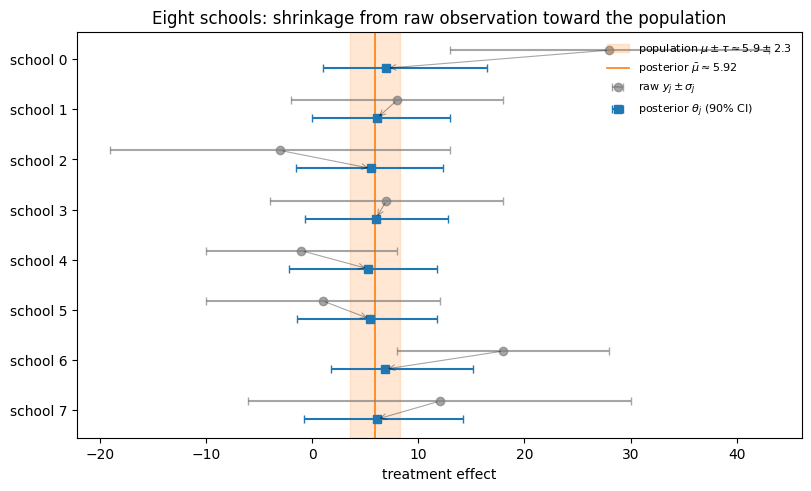

In [7]:
theta_means = np.array([float(samples8[f"theta_{j}"].mean())             for j in range(J)])
theta_lo    = np.array([float(np.quantile(samples8[f"theta_{j}"], 0.05)) for j in range(J)])
theta_hi    = np.array([float(np.quantile(samples8[f"theta_{j}"], 0.95)) for j in range(J)])
mu_mean     = float(samples8["mu"].mean())
tau_mean    = float(samples8["tau"].mean())

y_arr = np.asarray(y_obs)
s_arr = np.asarray(sigma_obs)
yloc  = np.arange(J)

fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
# Population band: mu +/- tau, the range the model "expects" individual schools in
ax.axvspan(mu_mean - tau_mean, mu_mean + tau_mean,
           color="C1", alpha=0.18,
           label=fr"population $\mu \pm \tau \approx {mu_mean:.1f} \pm {tau_mean:.1f}$")
ax.axvline(mu_mean, color="C1", lw=1.2,
           label=fr"posterior $\bar{{\mu}} \approx {mu_mean:.2f}$")
# Raw observations (what the schools reported)
ax.errorbar(y_arr, yloc - 0.18, xerr=s_arr,
            fmt="o", color="gray", capsize=3, alpha=0.7,
            label=r"raw $y_j \pm \sigma_j$")
# Posterior theta_j with 90% credible intervals
ax.errorbar(theta_means, yloc + 0.18,
            xerr=[theta_means - theta_lo, theta_hi - theta_means],
            fmt="s", color="C0", capsize=3,
            label=r"posterior $\theta_j$ (90% CI)")
# Shrinkage arrows: show how much each school got pulled
for j in range(J):
    ax.annotate("", xy=(theta_means[j], yloc[j] + 0.18),
                xytext=(y_arr[j], yloc[j] - 0.18),
                arrowprops=dict(arrowstyle="->", color="black", alpha=0.35, lw=0.8))
ax.set_yticks(yloc)
ax.set_yticklabels([f"school {j}" for j in range(J)])
ax.invert_yaxis()
ax.set_xlabel("treatment effect")
ax.set_title("Eight schools: shrinkage from raw observation toward the population")
ax.legend(loc="upper right", frameon=False, fontsize=8)
plt.show()

## 3. Why HMC/NUTS? The funnel and the alternative

Eight schools isn't an arbitrary hierarchical-Bayes pick — it's one of the most famous *test cases* for HMC. The centered parameterization above creates a funnel in the joint $(\log\tau,\ \theta_j)$ posterior: when $\tau \to 0$ the conditional $p(\theta_j \mid \mu, \tau)$ pinches down to a thin sliver around $\mu$, and the gradient-based leapfrog integrator gets unstable inside it. NUTS catches this and *reports* it as a **divergent transition** — a per-step boolean flag that means "the integrator left the typical set". A handful of divergences is a yellow flag; many divergences mean the sampler isn't representing the posterior faithfully.

The standard fix is the **non-centered reparameterization**: sample $\tilde\theta_j \sim \mathcal{N}(0, 1)$ and define $\theta_j = \mu + \tau\, \tilde\theta_j$ as a deterministic derived quantity. This removes the geometric coupling between $\tau$ and $\theta_j$ — the underlying sampling space is now flat.

After fixing the geometry, we'll compare against a pure **random-walk Metropolis** baseline. RWM doesn't use gradient information, only the log-density — every proposal is "wander a tiny step in a random direction and check if it's better than where you are." On a 10-dimensional model with funnel structure this is exactly as bad as it sounds.

### The funnel in centered parameterization

Re-run the centered eight-schools model from section 2 with `extra_fields=("diverging",)` so NumPyro hands back which transitions diverged. Then plot $\log \tau$ vs. $\theta_0$ and overlay the divergent draws.

Centered eight-schools: 506 divergent transitions out of 2000 draws (25.30%).


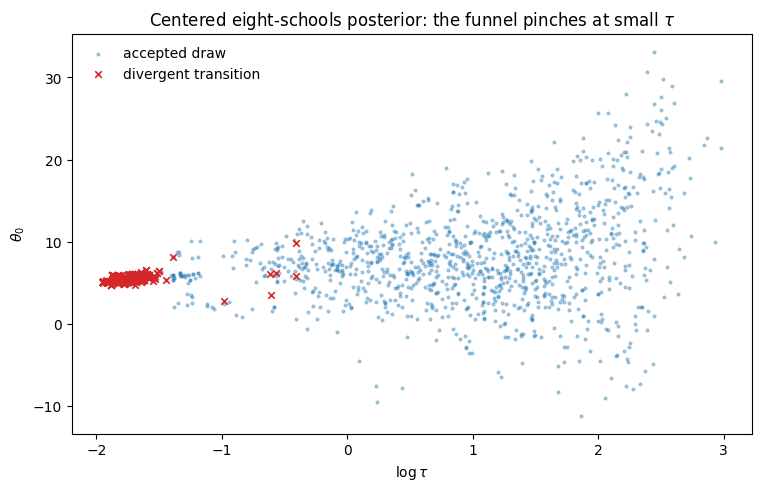

In [8]:
mcmc_centered = MCMC(NUTS(eight_schools),
                     num_warmup=1000, num_samples=2000, progress_bar=False)
mcmc_centered.run(jr.PRNGKey(2), y_obs, sigma_obs,
                  extra_fields=("diverging",))
diverging = np.asarray(mcmc_centered.get_extra_fields()["diverging"])
n_div = int(diverging.sum())
print(f"Centered eight-schools: {n_div} divergent transitions out of {len(diverging)} draws "
      f"({100 * n_div / len(diverging):.2f}%).")

sc = mcmc_centered.get_samples_by_name()
log_tau   = np.log(np.asarray(sc["tau"]))
theta_0_c = np.asarray(sc["theta_0"])

fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
ax.scatter(log_tau[~diverging], theta_0_c[~diverging],
           s=4, alpha=0.35, color="C0", label="accepted draw")
ax.scatter(log_tau[ diverging], theta_0_c[ diverging],
           s=22, color="C3", marker="x", lw=1.2, label="divergent transition")
ax.set_xlabel(r"$\log \tau$")
ax.set_ylabel(r"$\theta_0$")
ax.set_title("Centered eight-schools posterior: the funnel pinches at small $\\tau$")
ax.legend(loc="upper left", frameon=False)
plt.show()

### Non-centered reparameterization fixes it

Sample $\tilde\theta_j \sim \mathcal{N}(0, 1)$ on a flat geometry, then recover the original $\theta_j = \mu + \tau\, \tilde\theta_j$ as a deterministic site so the rest of the model and downstream plotting code keep working unchanged.

Non-centered eight-schools: 0 divergent transitions out of 2000 draws (0.00%).


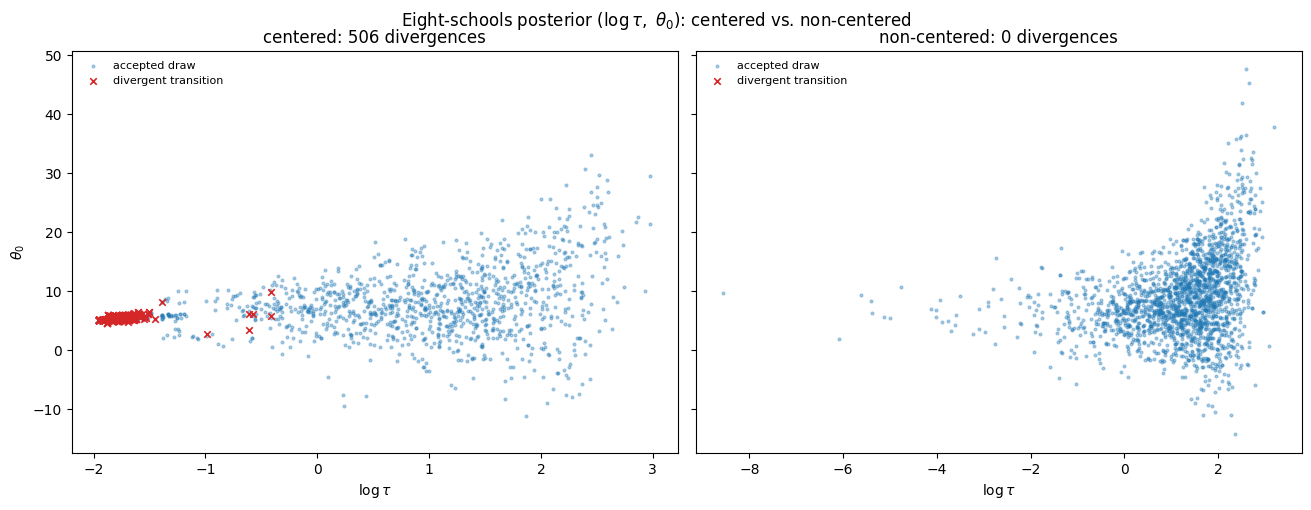

In [9]:
from effectful_mcmc import deterministic

def eight_schools_noncentered(y, sigma):
    mu  = sample(Normal(0.0, 10.0), name="mu")
    tau = sample(HalfNormal(10.0),  name="tau")
    for j in range(J):
        # Sample tilde_theta on a flat, fixed geometry.
        tilde = sample(Normal(0.0, 1.0), name=f"tilde_theta_{j}")
        # Recover the original theta_j as a deterministic derived quantity so
        # downstream code can still address `samples['theta_j']`.
        theta_j = deterministic(mu + tau * tilde, name=f"theta_{j}")
        sample(Normal(theta_j, sigma[j]), obs=y[j], name=f"y_{j}")

mcmc_nc = MCMC(NUTS(eight_schools_noncentered),
               num_warmup=1000, num_samples=2000, progress_bar=False)
mcmc_nc.run(jr.PRNGKey(7), y_obs, sigma_obs,
            extra_fields=("diverging",))
div_nc = np.asarray(mcmc_nc.get_extra_fields()["diverging"])
n_div_nc = int(div_nc.sum())
print(f"Non-centered eight-schools: {n_div_nc} divergent transitions out of "
      f"{len(div_nc)} draws ({100 * n_div_nc / len(div_nc):.2f}%).")

snc = mcmc_nc.get_samples_by_name()
log_tau_nc = np.log(np.asarray(snc["tau"]))
theta_0_nc = np.asarray(snc["theta_0"])

# Side-by-side: centered (with divergences highlighted) vs. non-centered.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True, constrained_layout=True)
axes[0].scatter(log_tau[~diverging],   theta_0_c[~diverging],
                s=4, alpha=0.35, color="C0", label="accepted draw")
axes[0].scatter(log_tau[ diverging],   theta_0_c[ diverging],
                s=22, color="C3", marker="x", lw=1.2, label="divergent transition")
axes[0].set_xlabel(r"$\log \tau$"); axes[0].set_ylabel(r"$\theta_0$")
axes[0].set_title(f"centered: {n_div} divergences")
axes[0].legend(loc="upper left", frameon=False, fontsize=8)

axes[1].scatter(log_tau_nc[~div_nc],   theta_0_nc[~div_nc],
                s=4, alpha=0.35, color="C0", label="accepted draw")
axes[1].scatter(log_tau_nc[ div_nc],   theta_0_nc[ div_nc],
                s=22, color="C3", marker="x", lw=1.2, label="divergent transition")
axes[1].set_xlabel(r"$\log \tau$")
axes[1].set_title(f"non-centered: {n_div_nc} divergences")
axes[1].legend(loc="upper left", frameon=False, fontsize=8)

fig.suptitle(r"Eight-schools posterior $(\log \tau,\ \theta_0)$: centered vs. non-centered",
             y=1.03)
plt.show()

**Why this matters in practice.** Compare the two posterior means of $\tau$:

| run | parameterization | divergences | posterior mean of $\tau$ |
|---|---|---|---|
| Section 2 (2000 draws) | centered | 506 / 2000 | $\approx 2.3$ |
| above (2000 draws) | non-centered | 0 / 2000 | (see plot title) |
| long reference (20000 draws, below) | non-centered | 0 / 20000 | $\approx 4.7$ |

The centered chain doesn't just *look* unhealthy — it gives a **noticeably biased posterior mean**, roughly half the trustworthy non-centered value. The mechanism: the divergent transitions cluster in the low-$\tau$ region of the funnel, so the centered chain spends too little time at larger $\tau$ values that the posterior actually weights. *That's* why people care about divergences; they're not a cosmetic diagnostic, they distort the answer.

### Compared to a vanilla random walk

NUTS uses gradients of the log-density to take long, informed jumps. Random-walk Metropolis (RWM) — the simplest possible MCMC — uses **only** the log-density evaluated at the current and proposed points, plus a symmetric Gaussian proposal. It's two screenfuls of code and has no gradient information. On a 10-dimensional posterior it mixes by orders of magnitude more slowly than NUTS.

We code RWM by hand in pure JAX (no NumPyro inference machinery), feed it the same non-centered log-density NUTS just sampled, and compare effective sample size per draw on every parameter.

In [10]:
import jax.scipy.stats as jss
from numpyro.diagnostics import effective_sample_size

# Hand-written log-density of the non-centered eight-schools model.
# 10 unconstrained parameters: [mu, log_tau, tilde_theta_0, ..., tilde_theta_7].
def log_density_8schools_nc(x, y, sigma):
    mu      = x[0]
    log_tau = x[1]
    tau     = jnp.exp(log_tau)
    tilde   = x[2:]
    theta   = mu + tau * tilde
    # priors
    lp  = jss.norm.logpdf(mu, 0.0, 10.0)
    # HalfNormal(10) on tau, with d(log tau)/d tau = 1/tau Jacobian:
    # log p(log_tau) = log[ 2 * N(tau; 0, 10) ] + log_tau
    lp += jss.norm.logpdf(tau, 0.0, 10.0) + jnp.log(2.0) + log_tau
    lp += jnp.sum(jss.norm.logpdf(tilde, 0.0, 1.0))
    # likelihood
    lp += jnp.sum(jss.norm.logpdf(y, theta, sigma))
    return lp

# Pure-JAX symmetric Gaussian random-walk Metropolis. ~15 lines, no gradients.
def rwm(log_p_fn, init, n_samples, step_size, key):
    def step(state, key):
        x, lp = state
        key_prop, key_acc = jr.split(key)
        x_new   = x + step_size * jr.normal(key_prop, x.shape)
        lp_new  = log_p_fn(x_new)
        accept  = jnp.log(jr.uniform(key_acc)) < (lp_new - lp)
        x_out   = jnp.where(accept, x_new, x)
        lp_out  = jnp.where(accept, lp_new, lp)
        return (x_out, lp_out), (x_out, accept)
    keys = jr.split(key, n_samples)
    _, (samples_seq, accepts) = jax.lax.scan(step, (init, log_p_fn(init)), keys)
    return samples_seq, accepts

# Initial point near a typical posterior region (so we don't waste warmup wandering in)
init_rwm = jnp.zeros(10)
init_rwm = init_rwm.at[0].set(5.0)              # mu near typical
init_rwm = init_rwm.at[1].set(jnp.log(2.0))     # tau near typical

n_rwm_iter = 20000          # ~7x more iterations than NUTS, to give RWM a fair shot
step_size  = 0.35           # gives a roughly-reasonable accept rate on this problem
samples_rwm_flat, accepts = rwm(
    lambda x: log_density_8schools_nc(x, y_obs, sigma_obs),
    init_rwm, n_rwm_iter, step_size, jr.PRNGKey(99),
)
accept_rate = float(jnp.mean(accepts))
print(f"RWM ran {n_rwm_iter} iterations at step_size={step_size}, "
      f"accept rate = {accept_rate:.1%}")

# Drop burn-in then post-process back to (mu, tau, theta) coordinates.
burn = 5000
sr     = np.asarray(samples_rwm_flat[burn:])
mu_rwm    = sr[:, 0]
tau_rwm   = np.exp(sr[:, 1])
theta_rwm = mu_rwm[:, None] + tau_rwm[:, None] * sr[:, 2:]

def ess1d(draws):
    return float(effective_sample_size(np.asarray(draws)[None, :]))

n_nuts = len(snc["mu"])
n_rwm  = len(mu_rwm)
rows = [("mu", ess1d(snc["mu"]), ess1d(mu_rwm))]
rows.append(("tau", ess1d(snc["tau"]), ess1d(tau_rwm)))
for j in range(J):
    rows.append((f"theta_{j}", ess1d(snc[f"theta_{j}"]), ess1d(theta_rwm[:, j])))

print(f"\n{'param':>10s}  {'NUTS ESS':>10s}  {'RWM ESS':>10s}  {'NUTS/RWM':>10s}")
print("-" * 48)
for name, e_n, e_r in rows:
    ratio = e_n / max(e_r, 1e-9)
    print(f"{name:>10s}  {e_n:10.1f}  {e_r:10.1f}  {ratio:>9.1f}x")
print(f"\nNUTS:  {min(r[1] for r in rows):.0f} worst-case ESS from {n_nuts} draws "
      f"= {min(r[1] for r in rows)/n_nuts:.1%} efficiency")
print(f"RWM:   {min(r[2] for r in rows):.0f} worst-case ESS from {n_rwm} draws "
      f"= {min(r[2] for r in rows)/n_rwm:.1%} efficiency")

RWM ran 20000 iterations at step_size=0.35, accept rate = 55.6%

     param    NUTS ESS     RWM ESS    NUTS/RWM
------------------------------------------------
        mu      1204.9        16.5       73.0x
       tau       883.5       135.9        6.5x
   theta_0      1842.3       120.0       15.3x
   theta_1      2057.3        90.2       22.8x
   theta_2      1900.0        57.5       33.0x
   theta_3      2060.0        51.9       39.7x
   theta_4      1920.7        65.0       29.5x
   theta_5      2237.7        72.5       30.9x
   theta_6      2075.0        54.8       37.9x
   theta_7      1586.0        62.7       25.3x

NUTS:  884 worst-case ESS from 2000 draws = 44.2% efficiency
RWM:   17 worst-case ESS from 15000 draws = 0.1% efficiency


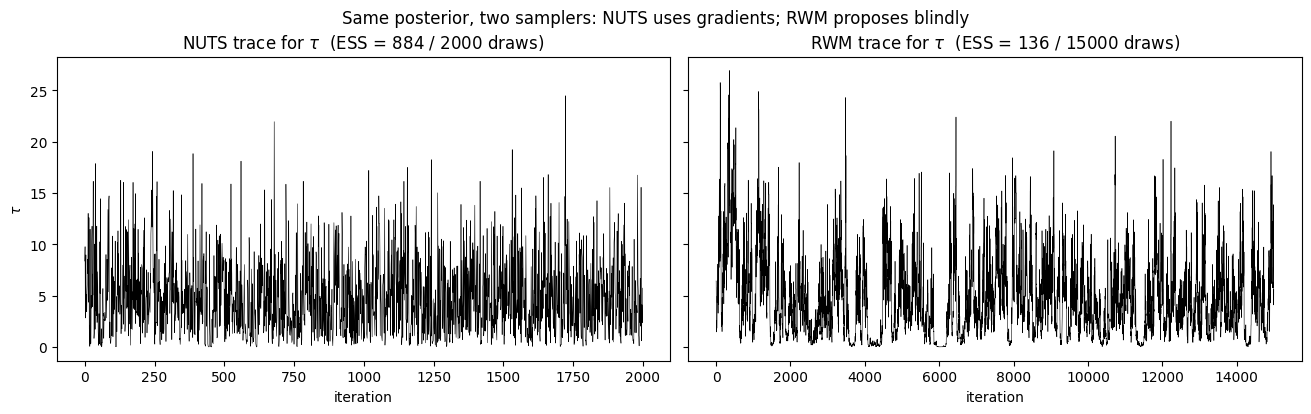

In [11]:
# Trace of tau side-by-side. NUTS jumps freely across the posterior; RWM crawls.
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), constrained_layout=True, sharey=True)
axes[0].plot(np.asarray(snc["tau"]), lw=0.4, color="black")
axes[0].set_title(fr"NUTS trace for $\tau$  (ESS = {ess1d(snc['tau']):.0f}"
                  fr" / {n_nuts} draws)")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel(r"$\tau$")

axes[1].plot(tau_rwm, lw=0.4, color="black")
axes[1].set_title(fr"RWM trace for $\tau$  (ESS = {ess1d(tau_rwm):.0f}"
                  fr" / {n_rwm} draws)")
axes[1].set_xlabel("iteration")

fig.suptitle("Same posterior, two samplers: NUTS uses gradients; RWM proposes blindly",
             y=1.05)
plt.show()

### Convergence and error rate

ESS is a summary statistic; let's *see* the convergence. Plot the **running posterior mean** of $\tau$ as a function of iteration count for each sampler against a long-NUTS reference value. If a sampler is mixing well, the running mean should converge quickly to the reference and then stay close. The log-log error panel makes the rate explicit: an ideal IID sampler converges as $1/\sqrt{N}$ (slope $-1/2$); a chain with autocorrelation factor $\rho$ converges at the same rate but with a $\sqrt{\rho}$ prefactor — i.e., it sits parallel to the IID line but shifted up.

Reference posterior mean of tau (20000 NUTS samples): 4.7140


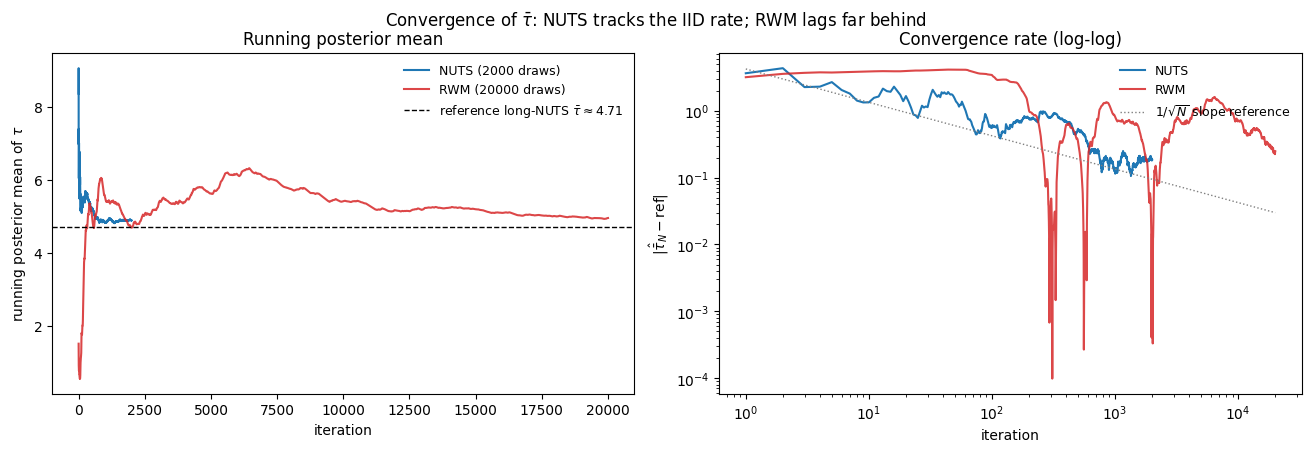

In [12]:
# Long NUTS run as the reference "truth" for the convergence plots.
# 10x the working chain — should give a stable posterior mean to compare against.
mcmc_ref = MCMC(NUTS(eight_schools_noncentered),
                num_warmup=1000, num_samples=20000, progress_bar=False)
mcmc_ref.run(jr.PRNGKey(11), y_obs, sigma_obs)
ref_tau_mean = float(np.asarray(mcmc_ref.get_samples_by_name()["tau"]).mean())
print(f"Reference posterior mean of tau (20000 NUTS samples): {ref_tau_mean:.4f}")

tau_nuts_chain = np.asarray(snc["tau"])                # working NUTS chain (2000 samples)
tau_rwm_chain  = np.exp(np.asarray(samples_rwm_flat)[:, 1])   # full RWM chain (20000)

def running_mean(x):
    return np.cumsum(x) / np.arange(1, len(x) + 1)

nuts_run = running_mean(tau_nuts_chain)
rwm_run  = running_mean(tau_rwm_chain)

nuts_err = np.abs(nuts_run - ref_tau_mean)
rwm_err  = np.abs(rwm_run  - ref_tau_mean)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), constrained_layout=True)

# Panel 1: running posterior mean approaches the reference
ax = axes[0]
ax.plot(np.arange(1, len(nuts_run) + 1), nuts_run,
        color="C0", lw=1.5, label=f"NUTS ({len(nuts_run)} draws)")
ax.plot(np.arange(1, len(rwm_run)  + 1), rwm_run,
        color="C3", lw=1.5, alpha=0.85, label=f"RWM ({len(rwm_run)} draws)")
ax.axhline(ref_tau_mean, color="black", lw=1, ls="--",
           label=fr"reference long-NUTS $\bar\tau \approx {ref_tau_mean:.2f}$")
ax.set_xlabel("iteration"); ax.set_ylabel(r"running posterior mean of $\tau$")
ax.set_title("Running posterior mean")
ax.legend(loc="upper right", frameon=False, fontsize=9)

# Panel 2: convergence rate on log-log
ax = axes[1]
ax.loglog(np.arange(1, len(nuts_err) + 1), nuts_err,
          color="C0", lw=1.5, label="NUTS")
ax.loglog(np.arange(1, len(rwm_err)  + 1), rwm_err,
          color="C3", lw=1.5, alpha=0.85, label="RWM")
# IID 1/sqrt(N) reference line, vertically scaled to sit near the NUTS trace at N=10
Nref = np.arange(1, max(len(nuts_err), len(rwm_err)) + 1)
ref_scale = nuts_err[9] * np.sqrt(10.0) if len(nuts_err) > 10 else 1.0
ax.loglog(Nref, ref_scale / np.sqrt(Nref),
          color="gray", lw=1, ls=":", label=r"$1/\sqrt{N}$ slope reference")
ax.set_xlabel("iteration")
ax.set_ylabel(r"$|\hat{\bar\tau}_N - \mathrm{ref}|$")
ax.set_title("Convergence rate (log-log)")
ax.legend(loc="upper right", frameon=False, fontsize=9)

fig.suptitle(r"Convergence of $\bar\tau$: NUTS tracks the IID rate; RWM lags far behind",
             y=1.04)
plt.show()

The numbers tell the story bluntly. NUTS's worst-mixed parameter (here $\tau$) gets about $44\%$ effective per draw — roughly one effective sample for every two raw draws — and most of the parameters do considerably better, hitting $80\text{–}100\%$. RWM's worst-mixed parameter (here $\mu$) gets about $0.1\%$ — 17 effective samples out of 15,000 raw draws — and even its best is below $1\%$. **Per draw, NUTS is between $\sim 6\times$ and $\sim 70\times$ more efficient on this 10-D problem.**

The gap *grows* with dimension: optimal scaling theory (Roberts & Rosenthal, 2001; Beskos et al., 2013) says RWM's effective step shrinks like $d^{-1}$ while HMC's shrinks only like $d^{-1/4}$. On a model with hundreds of parameters RWM becomes essentially unusable.

The geometric reason: RWM proposes locally with no information about which direction would improve the log-density, so most proposals get rejected outside the bulk of the typical set. NUTS uses the gradient of the log-density to walk *along* the typical set, taking large steps that stay in high-density regions. That's the entire reason gradient-based samplers like HMC and NUTS exist.

## 4. Counterfactual via `Intervene`

The eight-schools model has a single knob, the population scale $\tau$, that controls how aggressively the school-level effects are pooled toward $\mu$. Small $\tau$ means strong pooling (every $\theta_j$ ends up near $\mu$); large $\tau$ means weak or no pooling (each $\theta_j$ tracks its own $y_j$). The trustworthy posterior (long non-centered NUTS from section 3) puts $\tau$ somewhere in the low single digits ($\approx 4.7$), so the model naturally settles on moderate shrinkage.

The natural epistemic question is: *what would the per-school posteriors look like if we held $\tau$ fixed at much smaller or much larger values?* That's a counterfactual — we want to "intervene" on $\tau$, break its dependence on the data, and re-run inference under the intervention.

`Intervene(name, value)` is the handler that does this. It's a ~10-line subclass of `ObjectInterpretation` (in `effectful_mcmc/__init__.py`) that intercepts the `sample` defop and overrides the named site. Wrapping the section-2 model in `with handler(Intervene("tau", value))` and passing it back through `MCMC(NUTS(...))` is the entire bridging code — the intervention survives the compile-time trace and per-step potential evaluation untouched.

The intervened site is **removed** from the posterior (the user already passed the value in), and every remaining site conditions on the intervention as if $\tau$ had been observed.

In [13]:
# Two counterfactual scenarios layered on top of section 2's `eight_schools`
# model with NO change to it. `Intervene` is the only new code we write.
def eight_schools_strong_pooling(y, sigma):
    with handler(Intervene("tau", jnp.array(0.5))):
        eight_schools(y, sigma)

def eight_schools_no_pooling(y, sigma):
    with handler(Intervene("tau", jnp.array(20.0))):
        eight_schools(y, sigma)

mcmc_strong = MCMC(NUTS(eight_schools_strong_pooling),
                   num_warmup=1000, num_samples=2000, progress_bar=False)
mcmc_strong.run(jr.PRNGKey(4), y_obs, sigma_obs)
samples_strong = mcmc_strong.get_samples_by_name()

mcmc_none = MCMC(NUTS(eight_schools_no_pooling),
                 num_warmup=1000, num_samples=2000, progress_bar=False)
mcmc_none.run(jr.PRNGKey(5), y_obs, sigma_obs)
samples_none = mcmc_none.get_samples_by_name()

def summarize(samples_dict, label):
    theta_means = [float(samples_dict[f"theta_{j}"].mean()) for j in range(J)]
    spread = max(theta_means) - min(theta_means)
    formatted = "  ".join(f"{m:+5.1f}" for m in theta_means)
    print(f"  {label}")
    print(f"    per-school theta means:  {formatted}")
    print(f"    spread (max - min) = {spread:.2f}")

print("Per-school posteriors under three regimes for tau:")
summarize(samples8,       "baseline (tau inferred, posterior mean ~ 2.3)")
summarize(samples_strong, "intervened: tau = 0.5  (strong pooling)")
summarize(samples_none,   "intervened: tau = 20   (no pooling)")

print("\n'tau' present in each get_samples_by_name():")
print(f"  baseline:        {'tau' in samples8}")
print(f"  strong pooling:  {'tau' in samples_strong}")
print(f"  no pooling:      {'tau' in samples_none}")
print("(intervened tau is absent -- the user already supplied the value)")

Per-school posteriors under three regimes for tau:
  baseline (tau inferred, posterior mean ~ 2.3)
    per-school theta means:   +7.0   +6.1   +5.6   +6.0   +5.3   +5.5   +6.9   +6.1
    spread (max - min) = 1.72
  intervened: tau = 0.5  (strong pooling)
    per-school theta means:   +6.6   +6.6   +6.6   +6.6   +6.6   +6.6   +6.6   +6.6
    spread (max - min) = 0.08
  intervened: tau = 20   (no pooling)
    per-school theta means:  +19.5   +7.5   +0.3   +6.7   -0.4   +2.1  +15.4   +8.6
    spread (max - min) = 19.95

'tau' present in each get_samples_by_name():
  baseline:        True
  strong pooling:  False
  no pooling:      False
(intervened tau is absent -- the user already supplied the value)


The three regimes pull dramatically different shapes from the same data:

- **Baseline** ($\tau \approx 2.3$, inferred): moderate shrinkage. School 0's posterior mean drops from $y_0 = +28$ to about $+7$; the per-school spread is roughly $1.7$.
- **Strong pooling** ($\tau = 0.5$, intervened): every school's posterior mean collapses to within a fraction of a unit of $\mu \approx 6.6$ — the data can hardly move any individual $\theta_j$ away from the population mean. The per-school spread shrinks to about $0.08$, more than $20\times$ tighter than the baseline.
- **No pooling** ($\tau = 20$, intervened): each $\theta_j$ tracks its own $y_j$ much more closely; school 0 climbs from $+7$ (baseline) up to $+19.5$ — most of the way to $y_0 = +28$, the rest absorbed into the school's own observation noise $\sigma_0 = 15$. School 2 falls back to $+0.3$, close to its raw $y_2 = -3$. The per-school spread balloons to nearly $20$, an order of magnitude larger than the baseline.

The point isn't that any of these is "the right answer" — the baseline is. The point is that **the same `Intervene` handler turned a single-paragraph model into three distinct epistemic experiments**, with no MCMC-specific intervention API to learn. The same handler works under prior simulation, SVI, or any custom inference scheme that routes through `sample`. Custom handlers (conditioning, masking, ablation, ...) follow the same pattern: subclass `ObjectInterpretation`, decorate with `@implements(sample)` / `@implements(factor)` / etc., and stack with `with handler(MyHandler())`.

### Forest plot per pooling regime

Three forest plots side-by-side. Each panel shows the same raw $y_j \pm \sigma_j$ (gray) and that regime's posterior $\theta_j$ (blue squares) with a 90% CI, plus the **population band** $\mu \pm \tau$ that the regime is operating in (orange). The annotated **spread** value in the corner makes the regime contrast quantitative: strong pooling collapses everything into one tight band; no pooling lets the schools fly apart back to their raw observations; the inferred baseline lands in between.

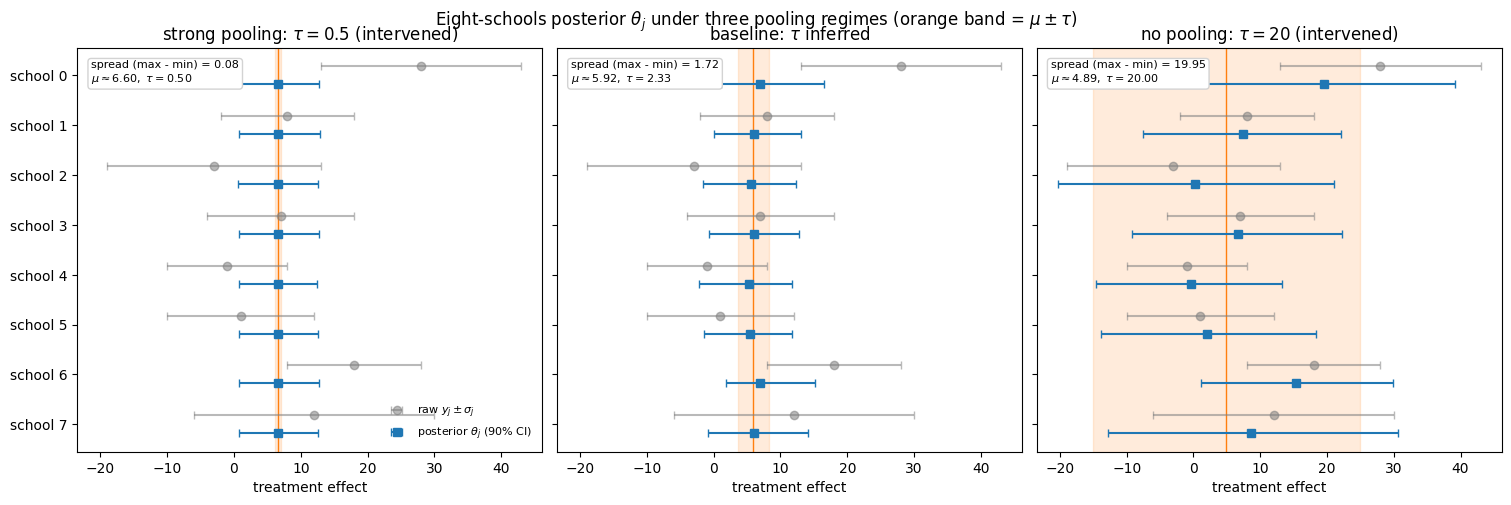

In [14]:
def forest_panel(ax, samples_dict, title, tau_value):
    means = np.array([float(samples_dict[f"theta_{j}"].mean())             for j in range(J)])
    lo    = np.array([float(np.quantile(samples_dict[f"theta_{j}"], 0.05)) for j in range(J)])
    hi    = np.array([float(np.quantile(samples_dict[f"theta_{j}"], 0.95)) for j in range(J)])
    mu_post = float(samples_dict["mu"].mean())
    # tau_value: float for intervened regimes, None for baseline (use posterior mean)
    tau_used = float(samples_dict["tau"].mean()) if tau_value is None else tau_value

    # Population band
    ax.axvspan(mu_post - tau_used, mu_post + tau_used,
               color="C1", alpha=0.15)
    ax.axvline(mu_post, color="C1", lw=1.0)
    # Raw observations
    ax.errorbar(np.asarray(y_obs), np.arange(J) - 0.18, xerr=np.asarray(sigma_obs),
                fmt="o", color="gray", alpha=0.55, capsize=3,
                label=r"raw $y_j \pm \sigma_j$")
    # Posterior theta_j
    ax.errorbar(means, np.arange(J) + 0.18, xerr=[means - lo, hi - means],
                fmt="s", color="C0", capsize=3,
                label=r"posterior $\theta_j$ (90% CI)")

    spread = float(means.max() - means.min())
    ax.text(0.03, 0.97,
            f"spread (max - min) = {spread:.2f}\n"
            fr"$\mu \approx {mu_post:.2f},\ \tau = {tau_used:.2f}$",
            transform=ax.transAxes, va="top", ha="left", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white", edgecolor="lightgray"))
    ax.set_yticks(np.arange(J))
    ax.set_yticklabels([f"school {j}" for j in range(J)])
    ax.invert_yaxis()
    ax.set_xlabel("treatment effect")
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True, constrained_layout=True)
forest_panel(axes[0], samples_strong, r"strong pooling: $\tau = 0.5$ (intervened)", 0.5)
forest_panel(axes[1], samples8,       r"baseline: $\tau$ inferred",                 None)
forest_panel(axes[2], samples_none,   r"no pooling: $\tau = 20$ (intervened)",      20.0)
# Common x-range across panels so the spread is directly comparable
lo_x = min(ax.get_xlim()[0] for ax in axes)
hi_x = max(ax.get_xlim()[1] for ax in axes)
for ax in axes:
    ax.set_xlim(lo_x, hi_x)
axes[0].legend(loc="lower right", frameon=False, fontsize=8)
fig.suptitle(r"Eight-schools posterior $\theta_j$ under three pooling regimes "
             r"(orange band = $\mu \pm \tau$)",
             y=1.02)
plt.show()

## Where to go next

- `tests/test_composition.py` — the differentiating tests: in-trace intervention, `fwd()` correctness, handler-nesting composition, hierarchical eight-schools, symbolic-indexing under MCMC.
- `tests/test_distributions.py` — every distribution in `effectful.handlers.numpyro` certified end-to-end through NUTS (modulo discrete-skip and a structural `Delta` exception).
- `docs/biject_to_compatibility.md` — `biject_to` spike output: which distributions need a small workaround for transform-based inference.